In [4]:
import json
import os
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import batch_utils

In [11]:
# Experiment definition
exp_group = 'batch_rxbkg_unconn_state1_mech1'
exp_name = 'net_newsec_var_seed'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name

exp_names_sub = {
    'unconn': 'exp_ctx_unconn_nseed_5_t_6.0_10.0_wmult_0.25_ee_0.5',
    'ee_0': 'exp_ctx_ee_0_nseed_5_t_6.0_10.0_wmult_0.25_ee_0.5',
    'full':'exp_ctx_ee_1_nseed_5_t_6.0_10.0_wmult_0.25_ee_0.5',
}

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

pop_names = df.index.tolist()

In [13]:
R_all = {}

for exp_label, exp_name_sub in exp_names_sub.items():
    # Find json files with sim esults
    dirpath_data = dirpath_res / exp_name_sub / 'results'
    json_files = sorted(dirpath_data.glob('*.json'))
    n_trials = len(json_files)

    # Extract population rates from json files
    R = np.full((len(pop_names), n_trials), np.nan)
    for i, fpath in enumerate(json_files):
        with open(fpath, 'r') as fid:
            res = json.load(fid)
        for j, pop in enumerate(pop_names):
            R[j, i] = res['rates'].get(pop, np.nan)

    R = xr.DataArray(
        R,
        dims=['pop', 'trial'],
        coords={'pop': pop_names, 'trial': np.arange(n_trials)}
    )

    # Drop populations that have no valid rate in any trial
    R_all[exp_label] = R.sel(pop=~R.isnull().all(dim='trial'))


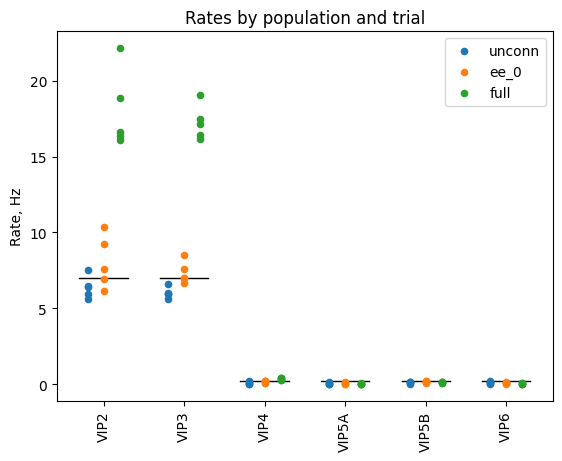

In [33]:
#pops_vis = ['IT2', 'IT3', 'PV2', 'PV3', 'SOM2', 'SOM3']
pops_vis = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']

d = 0.2
s = 20

#fig, ax = plt.subplots(figsize=(18, 6))
fig, ax = plt.subplots()

exp_labels = list(R_all.keys())
x_base = np.arange(len(pops_vis))
offsets = np.linspace(-d, d, len(exp_labels))
colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

for ix, pop in enumerate(pops_vis):
    target = df.loc[pop, 'target_rate']
    d1 = d * 1.5
    ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
            color='black', linewidth=1, linestyle='-', zorder=0)

for offset, exp_label in zip(offsets, exp_labels):
    R_exp = R_all[exp_label].reindex(pop=pops_vis)

    for ix, pop in enumerate(pops_vis):
        y = R_exp.sel(pop=pop).values
        y = y[~np.isnan(y)]
        if len(y) == 0:
            continue

        x = np.full(len(y), x_base[ix] + offset)
        ax.scatter(x, y, s=s, alpha=1, color=colors[exp_label],
                   label=exp_label if ix == 0 else None)

ax.set_xticks(x_base)
ax.set_xticklabels(pops_vis, rotation=90)
#ax.set_xlabel('pop')
ax.set_ylabel('Rate, Hz')
ax.set_title('Rates by population and trial')
ax.legend()   #title='exp_label')
#ax.grid(axis='y', alpha=0.3)
#plt.tight_layout()

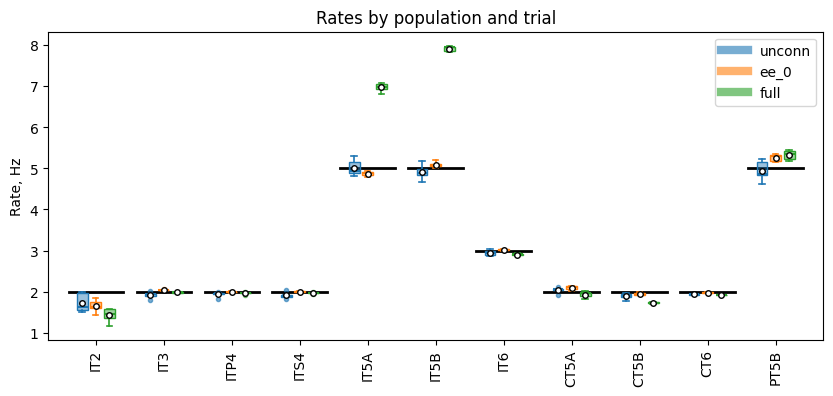

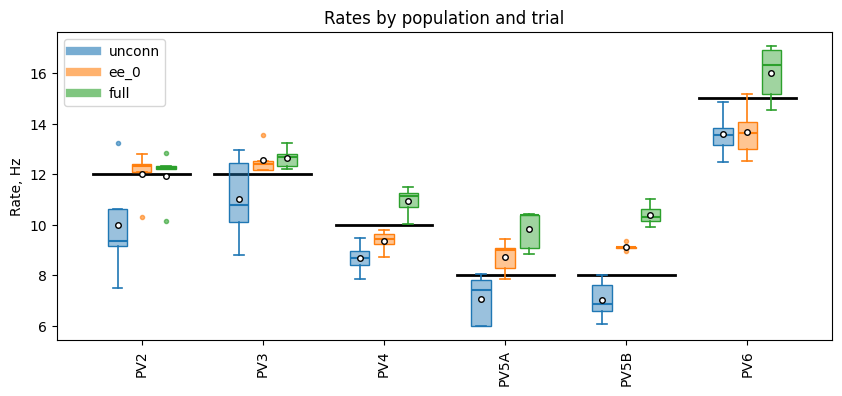

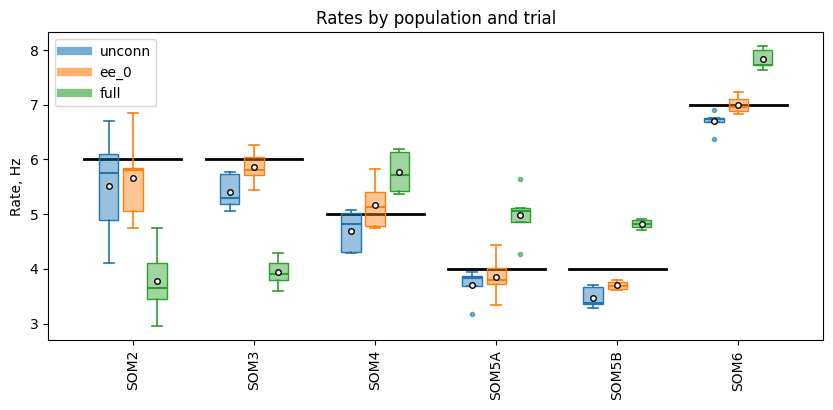

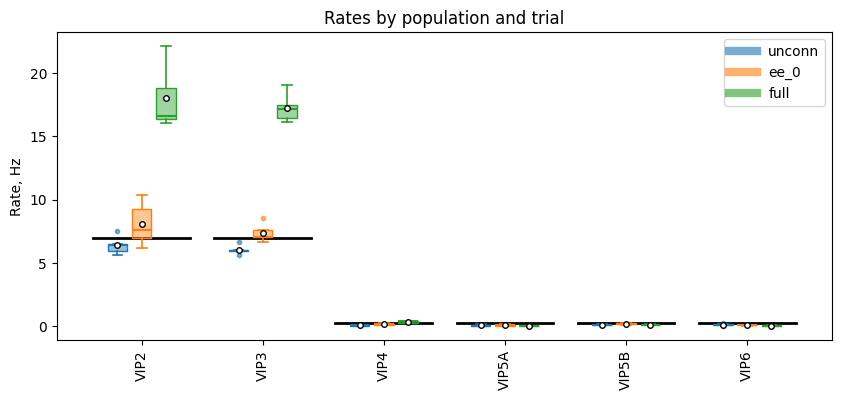

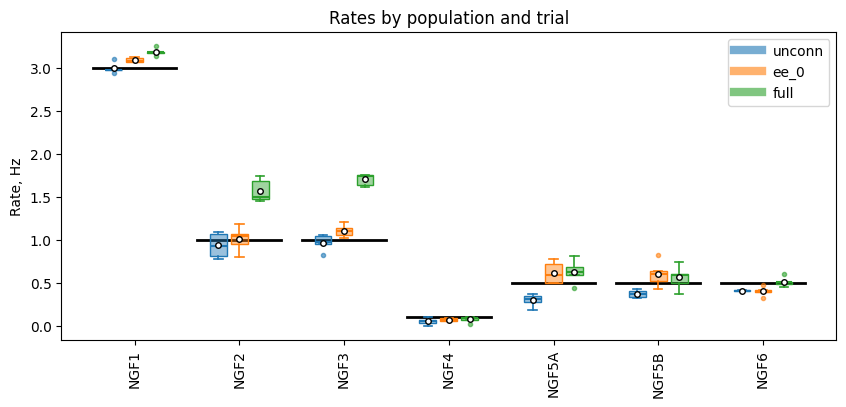

In [45]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

d = 0.2
d1 = d * 2
alpha = 0.6

def plot_rates(pops_vis):
    fig, ax = plt.subplots(figsize=(10, 4))

    exp_labels = list(R_all.keys())
    x_base = np.arange(len(pops_vis))
    offsets = np.linspace(-d, d, len(exp_labels))
    colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

    # Target horizontal markers
    for ix, pop in enumerate(pops_vis):
        target = df.loc[pop, 'target_rate']
        ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
                color='black', linewidth=2, linestyle='-', zorder=0, alpha=1)

    # Grouped boxplots
    box_w = 0.16
    box_props = lambda c: dict(
        patch_artist=True, showmeans=True, meanline=False, whis=1.5, vert=True,
        boxprops=dict(facecolor=(*c, 0.45), edgecolor=c),
        medianprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.2),
        capprops=dict(color=c, linewidth=1.2),
        meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=4),
        flierprops=dict(marker='.', markerfacecolor=c, markeredgecolor=c, alpha=alpha),
    )

    for offset, exp_label in zip(offsets, exp_labels):
        R_exp = R_all[exp_label].reindex(pop=pops_vis)
        data = [R_exp.sel(pop=pop).values for pop in pops_vis]
        data = [y[~np.isnan(y)] for y in data]
        positions = [x_base[ix] + offset for ix, y in enumerate(data) if len(y) > 0]
        data_valid = [y for y in data if len(y) > 0]

        ax.boxplot(data_valid, positions=positions, widths=box_w,
                **box_props(colors[exp_label]))

    # Simple legend
    handles = [plt.Line2D([0], [0], color=colors[k], lw=6, alpha=alpha, label=k) for k in exp_labels]
    ax.legend(handles=handles)

    ax.set_xticks(x_base)
    ax.set_xticklabels(pops_vis, rotation=90)
    ax.set_ylabel('Rate, Hz')
    ax.set_title('Rates by population and trial')

plot_rates(PYR_POPS)
plot_rates(PV_POPS)
plot_rates(SOM_POPS)
plot_rates(VIP_POPS)
plot_rates(NGF_POPS)